In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

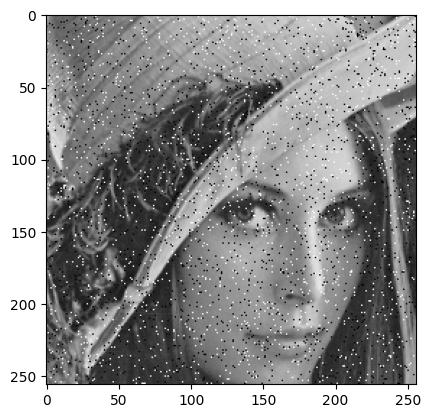

In [3]:
img = cv2.imread("image.png",0)
plt.imshow(img,cmap='grey')

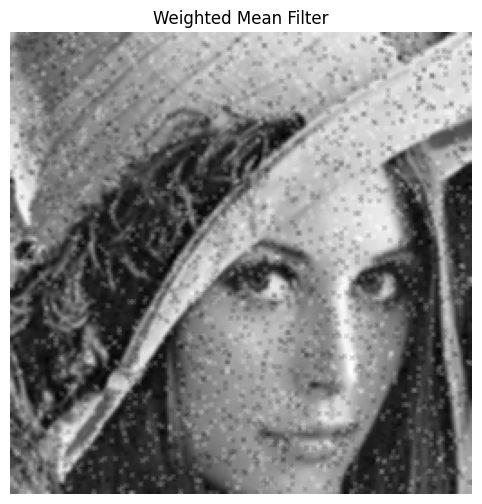

In [ ]:
weighted_kernel=np.asarray([[1,1,1],[1,2,1],[1,1,1]],dtype=np.float32)
weighted_kernel/=np.sum(weighted_kernel)

weighted_mean=cv2.filter2D(img,-1,weighted_kernel)
plt.figure(figsize=(8,6))
plt.imshow(weighted_mean,cmap='grey')
plt.title('Weighted Mean Filter')
plt.axis('off')
plt.show()

#if size of the kernel increases then smothening increases but edges are blurred more.
#  If we want to smoothen the image but preserve the edges then we can use gaussian filter.
#  It is a low pass filter which is used to remove noise and reduce detail in an image. It is a linear filter
#  which uses a gaussian function for calculating the transformation to apply to each pixel in the image. 

In [ ]:
g0=cv2.GaussianBlur(img,(5,5),sigmaX=0)
g1=cv2.GuassianBlur(img,(5,5),sigmaX=1)
#here increasing the value of sigma X increases the amount of smoothing. The larger the value of sigma, the more the image will be blurred.


[[  -8.   -2.  -72. ...  -44.    2. -278.]
 [  10.  -26.   20. ...   16. -127.  680.]
 [ -72.   12.    5. ...   42.   -4. -227.]
 ...
 [ -30.   12.   23. ...    8.  -16.   -4.]
 [  60.  -66.   70. ...   12.   -8.   16.]
 [  64.  -40.  -40. ...    6.   -2.    4.]]


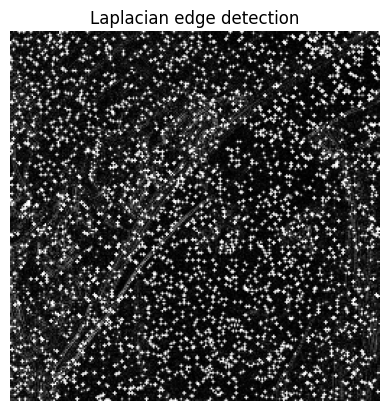

In [9]:
laplacian=cv2.Laplacian(img,cv2.CV_64F)
laplacian=np.asarray(laplacian)
print(laplacian)
laplacian_abs=cv2.convertScaleAbs(laplacian)
plt.imshow(laplacian_abs,cmap='gray')
plt.title('Laplacian edge detection')
plt.axis('off')
plt.show()

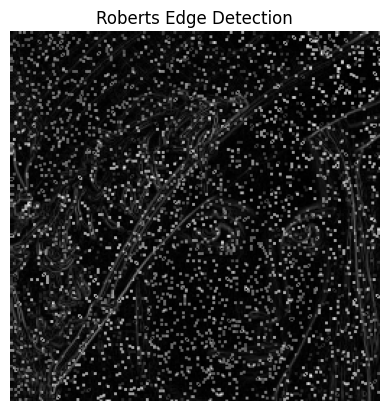

In [10]:
roberts_x=np.asarray([[1,0],[0,-1]],dtype=np.float32)
roberts_y=np.asarray([[0,1],[-1,0]],dtype=np.float32)

gx=cv2.filter2D(img.astype(np.float32),cv2.CV_32F,roberts_x)
gy=cv2.filter2D(img.astype(np.float32),cv2.CV_32F,roberts_y)
roberts=cv2.magnitude(gx,gy)
roberts=cv2.normalize(roberts,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(roberts,cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')
plt.show()

In [ ]:
prewitt_x=np.asarray([[-1,0,1],[-1,0,1],[-1,0,1]],dtype=np.float32)
prewitt_y=np.asarray([[-1,-1,-1],[0,0,0],[1,1,1]],dtype=np.float32)



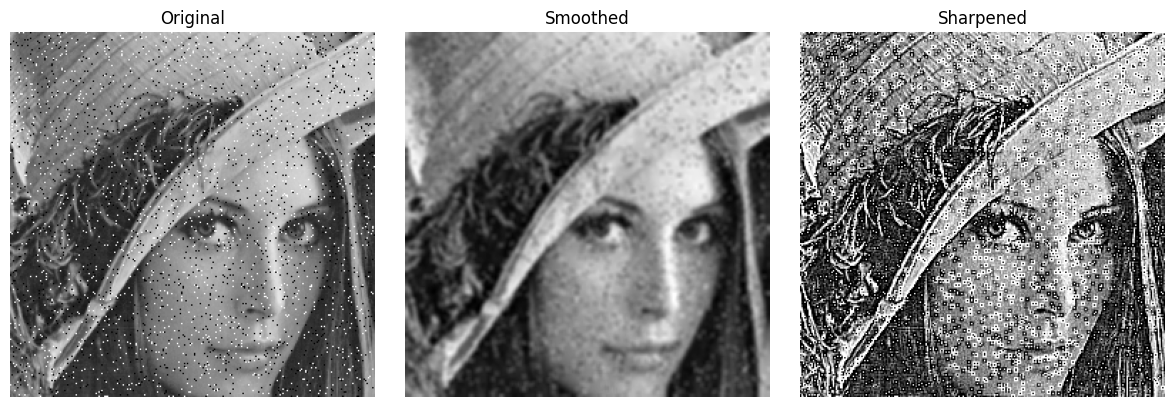

In [46]:
kernel_size = (5, 5)
sigma = 1.5
gaussian_kernel = cv2.getGaussianKernel(kernel_size[0], sigma)
gaussian_kernel = np.outer(gaussian_kernel, gaussian_kernel)
# Apply Gaussian smoothing
smoothed_image = cv2.filter2D(img, -1, gaussian_kernel)

sharpening_kernel = np.array([[-1, -1, -1],[-1, 9, -1], [-1, -1, -1]])
sharpened_image = cv2.filter2D(img, -1, sharpening_kernel)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(smoothed_image, cmap='gray')
plt.title("Smoothed")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpened_image, cmap='gray')
plt.title("Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

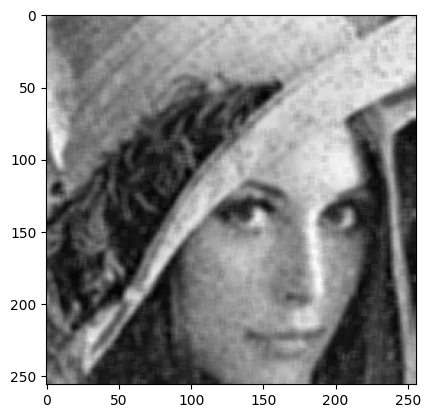

In [47]:
kernel_size = (5, 5) # You can adjust the size based on the desired smoothing level
# Create the Averaging filter kernel
kernel = np.ones(kernel_size, dtype=np.float32) / (kernel_size[0] *kernel_size[1])
# Apply the Averaging filter for smoothing
smoothed_image = cv2.filter2D(img, -1, kernel)
# Display the original and smoothed images
plt.imshow(smoothed_image,cmap='gray')

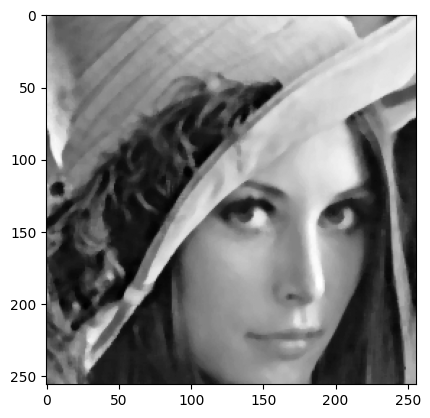

In [48]:
kernel_size = 5 # You can adjust the size based on the desired smoothing level
# Apply the Median filter for smoothing
smoothed_image = cv2.medianBlur(img, kernel_size)
# Display the original and smoothed images
plt.imshow(smoothed_image,cmap='grey')


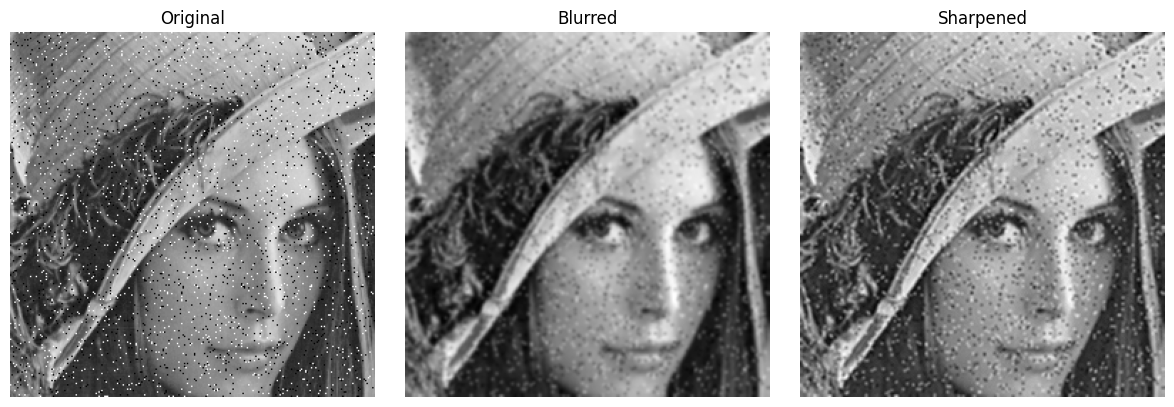

In [49]:
blurred_image = cv2.GaussianBlur(img, (5, 5), 0)
# Create a Laplacian kernel for sharpening
laplacian_kernel = np.array([[0, -1, 0],[-1, 5, -1],[0, -1, 0]], dtype=np.float32)
# Apply the Laplacian filter for sharpening
sharpened_image = cv2.filter2D(blurred_image, -1, laplacian_kernel)
# Display the original image, blurred image, and sharpened image

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blurred_image, cmap='gray')
plt.title("Blurred")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpened_image, cmap='gray')
plt.title("Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()